## 8.3 하이퍼파라미터를 이용한 성능 최적화
하이퍼파라미터를 이용한 성능 최적화의 추가적인 방법으로 배치 정규화, 드롭아웃, 조기 종료가 있습니다.

먼저 배치 정규화부터 살펴보겠습니다.

### 8.3.1 배치 정규화를 이용한 성능 최적화
배치 정규화를 진행하기에 앞서 유사한 의미로 사용되는 용어들을 알아보겠습니다.

**정규화**
정규화는 데이터 범위를 사용자가 원하는 범위로 제한하는 것을 의미합니다. 예를 들어 이미지 데이터는 픽셀 정보로 0~255 사이의 값을 갖는데, 이를 255로 나누면 0~1.0 사이의 값을 갖게 됩니다.

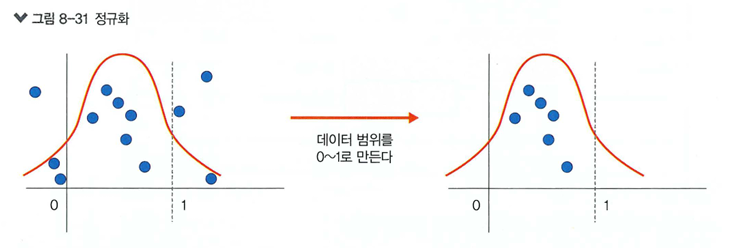

정규회는 각 특성 범위(스케일)를 조정한다는 의미로 특성 스케일링이라고도 합니다. 스케일 조정을 위해 MinMaxScalar() 기법을 사용하므로 수식은 다음과 같습니다.

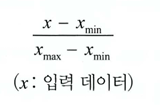

**규제화**
규제화는 모텔 복잡도를 줄이기 위해 제약을 두는 방법입니다. 이때 제약은 데이터가 네트워크에 들어가기 전에 필터를 적용한 것이라고 생각하면 됩니다. 예를 들어 디음 왼쪽 그림은 필터가 적용되지 않을 경우 모든 데이터가 네트워크에 투입되지만 오른쪽 그림은 필터로 걸러진 데이터만 네트워크에 투입되어 빠르고 정확한 결괴를 얻을 수 있습니다.

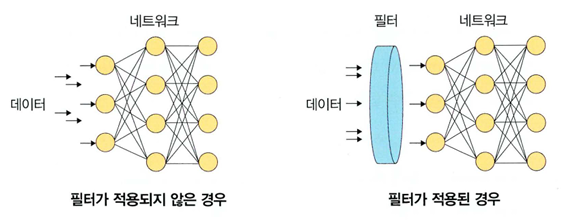

규제를 이용하여 모델 복잡도를 줄이는 방법은 다음과 같습니다.
- 드롭이웃
- 조기종료

**표준화**
표준화는 기존 데이터를 평균은 0, 표준편차는 1인 형태의 데이터로 만드는 방법입니다. 다른 표현으로 스칼라 혹은 z-스코어 정규화라고도 합니다.

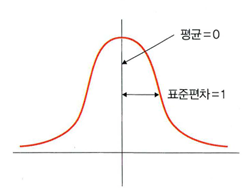

평균을 기준으로 얼마나 떨어져 있는지 살펴볼 때 사용합니다. 보통 데이터 분포가 가우시안 분포를 따를 때 유용한 방법으로 다음 수식을 사용합니다.

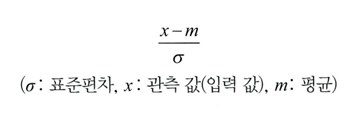

**배치 정규화**
배치 정규화는 데이터 분포가 안정되어 학습 속도를 높일 수 있습니다.

배치 정규회는 기울기 소멸이나 기울기 폭발 같은 문제를 해결하기 위한 방법입니다. 일반적으로 기울기 소멸이나 폭발 문제를 해결하기 위해 손실 함수로 렐루를 시용하거나 초깃값 튜닝 학습률 등을 조정합니다.

- 기울기 소멸: 오차 정보를 역전파시키는 과정에서 기울기가 급격히 0에 가까워져 학습이 되지 않는 현상입니다.
- 기울기 폭발: 학습 과정에서 기울기가 급격히 커지는 현상입니다.

배치 정규화가 소개된 논문에 따르면 기울기 소멸과 폭발 원인은 내부 공변량 변화 때문인데, 이것은 네트워크의 각 층마다 활성화 함수가 적용되면서 입력 값들의 분포가 계속 바뀌는 현상을 의미합니다. 따라서 분산된 분포를 정규분포로 만들기 위해 표준화와 유사한 방식을 미니 배치에 적용하여 평균은 0으로, 표준편차는 1로 유지하도록 하며 수식은 다음과 같습니다.

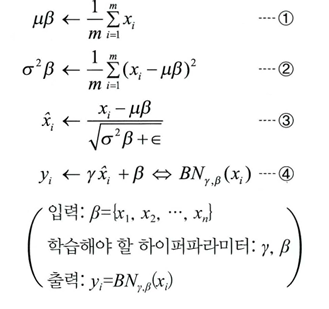

1. 미니 배치 평균을 구합니다.
2. 미니 배치의 분산과 표준편차를 구합니다.
3. 정규화를 수행합니다.
4. 스케일을 조정(데이터 분포 조정)합니다.

따라서 매 단계마다 활성화 함수를 거치면서 데이터셋 분포가 일정해지기 때문에 속도를 향상시킬 수 있지만 다음과 같은 단점도 있습니다.

첫째, 배치 크기가 작을 때는 정규화 값이 기존 값과 다른 방향으로 훈련될 수 있습니다. 예를 들어 분산이 0이면 정규화 자체가 안 되는 경우가 생길 수 있습니다.

둘째, RNN은 네트워크 계층별로 미니 정규화를 적용해야 하기 때문에 모델이 더 복잡해지면서 비효율적일 수 있습니다.

따라서 이러한 문제들을 해결하기 위한 가중치 수정, 네트워크 구성 변경 등을 수행하지만, 무엇보다 중요한 것은 배치 정규화를 적용하면 적용하지 않았을 때보다 성능이 좋아지기 때문에 많이 사용됩니다.

### 8.3.2 드롭아웃을 이용한 성능 최적화
과적합은 훈련 데이터셋을 과하게 학습하는 것을 의미합니다. 그렇다면 과하게 훈련 데이터셋을 학습하는 것이 왜 문제일까요? 일반적으로 훈련 데이터셋은 실제 데이터셋의 부분 집합이므로 훈련 데이터셋에 대해서는 오류가 감소하지만, 테스트 데이터셋에 대해서는 오류가 증가합니다. 즉, 훈련 데이터셋에 대해 훈련을 계속한다면 오류는 줄어들지만 테스트 데이터셋에 대한 오류는 어느 순간부터 증가하는데 이러한 모델을 과적합되어 있다고 합니다.

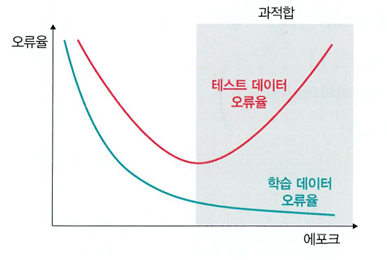

드롭아웃(dropout)이란 훈련할 때 일정 비율의 뉴런만 사용하고 나머지 뉴런에 해당하는 가중치는 업데이트하지 않는 방법입니다. 물론 매 단계마다 사용하지 않는 뉴런을 바꾸어 가며 훈련시킵니다. 즉, 드롭아웃은 노드를 임의로 끄면서 학습하는 방법으로, 은닉층에 배치된 노드 중 일부를 임의로 끄면서 학습합니다. 꺼진 노드는 신호를 전달하지 않으므로 지나친 학습을 방지하는 효과가 생깁니다.

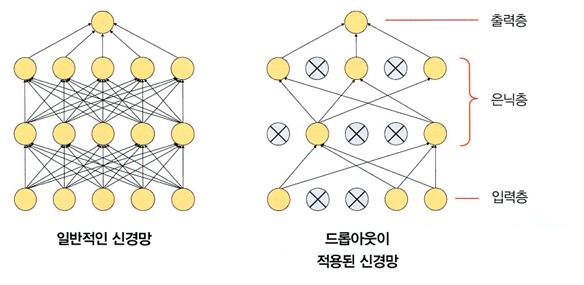

그림의 왼쪽은 일반적인 신경망이고 오른쪽은 드롭아웃이 적용된 신경망의 모습입니다. 일부 노드들은 비활성화되고 남은 노드들로 신호가 연결되는 신경망 형태를 띠고 있습니다. 어떤 노드를 비활성화할지는 학습할 때마다 무작위로 선정되며, 테스트 데이터로 평가할 때는 노드들을 모두 사용하여 출력하되 노드 삭제 비율(드롭이웃 비율)을 곱해서 성능을 평가합나다.

드롭아웃을 사용하면 훈련 시간이 길어지는 단점이 있지만, 모델 성능을 향상하기 위해 상당히 자주 쓰는 방법입니다.

그럼 배치 정규화와 드롭아웃에 대한 파이토치 예제를 알아보겠습니다. 여기에서 시용되는 데이터셋은 파이토치 torchvision. datasets에서 제공하는 FashionMNIST 데이터셋입니다.

먼저 필요한 라이브러리를 호출합니다.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

예제에서 사용할 FashionMNIST 데이터셋을 내려받습니다.

In [2]:
trainset = torchvision.datasets.FashionMNIST(
    root = './data',
    train = True,
    download = True,
    transform = transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.2MB/s]


내려받은 데이터셋을 메모리로 가져옵니다. 단 trainloader 변수가 호출될 때 메모리로 가져오게 됩니다.

In [3]:
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

batch_size를 4로 설정했기 때문에 데이터를 메모리로 가져올 때 한 번에 네 개씩 쪼개서 가져옵니다.

이제 데이터셋을 이미지와 레이블로 분리하여 학습을 위한 준비를 합니다. 분리된 데이터셋에 대한 정보를 확인해 보겠습니다.

In [4]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
0


출력의 크기가 의미하는 내용은 다음과 같습니다.
4: 한번의 배치 크기고 몇 개의 데이터를 가져오는지 의미합니다. 앞에서 batch_size=4를 지정했기 때문에 4를 출력했습니다.
1: 채널을 의미하는 것으로 흑백 이미지는 1을 출력하며, 컬러 이미지는 3을 출력합니다.
28,28: 28x28(너비x높이) 픽셀 크기의 이미지라는 의미입니다.

예제에서 사용하고 있는 데이터셋의 이미지 몇 개만 출력해 보겠습니다. 먼저 이미지 출력을 위해 데이터 형태를 바꾸어 주기 위한 전처리 함수를 생성합니다.

In [6]:
def imshow(img, title):
    plt.figure(figsize = (batch_size * 4, 4)) # 출력할 개별 이미지의 크기 지정
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0))) # 1
    plt.title(title)
    plt.show()

1. 기본적으로 파이토치는 이미지 데이터셋을 [배치 크기 채널， 너비 높이(batch size, channel, width, height)] 순서대로 저장합니다. 하지만 이를 맷플롯립으로 출력하기 위해서는 이미지가 [너비, 높이, 채널] 형태이어야 합니다. 즉, 데이터의 형태 변경이 필요한데, 이때 시용할 수 있는 것이 넘파이 라이브러리의 transpose()입니다.

이제 이미지 출력을 위한 그래프 방식을 정의합니다.

In [8]:
def show_batch_images(dataloader):
  images, labels = next(iter(dataloader)) # 이미지의 크기는 (4,28,28,1(배치 크기, 높이, 너비, 채널))이 됩니다.

  img = torchvision.utils.make_grid(images) # 좌쵸에 이미지 픽셀을 대응시켜 그리드 형태로 출력합니다.
  imshow(img, title=[str(x.item()) for x in labels]) # imshow 함수를 사용함으로써 데이터의 형태는 (채널, 높이, 너비)에서 (높이, 너비, 채널)로 변경됩니다.

  return images, labels

앞에서 생성한 함수를 이용하여 이미지를 출력해 봅니다.

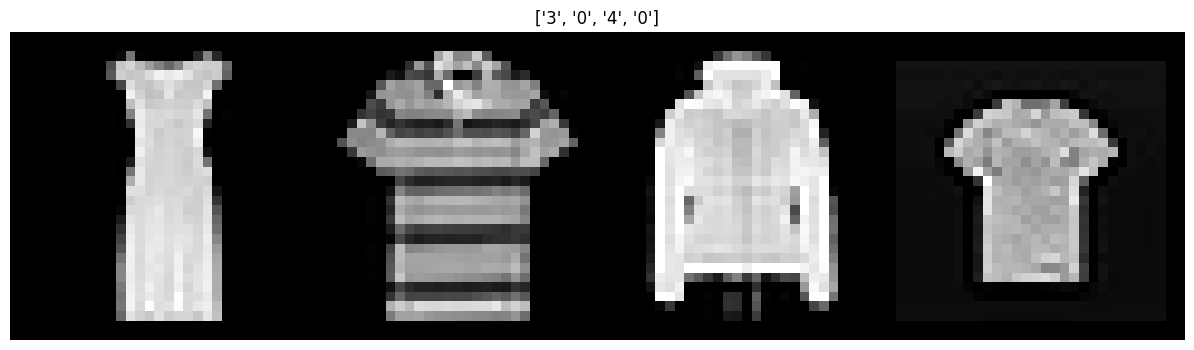

In [12]:
images, labels = show_batch_images(trainloader)

가장 상위에 표시된 숫자는 클래스(레이블)를 의미합니다.

따라서 '5'는 샌들, '6'은 셔츠, '4'는 코트, '3'은 드레스를 의미하는데 출력된 이미지와 동일함을 확인할 수 있습니다.

또한, 네 개의 이미지가 출력되는 이유는 한 변의 배치에서 네 개의 이미지만 가져오도록 했기 때문입니다.

이제 모델의 네트워크를 구축해야 합니다. 배치 정규화가 적용된 모델과 비교를 위해 배치 정규화가 적용되지 않는 모델을 먼저 생성해 보겠습니다.

In [14]:
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48), # (28,28) 크기의 이미지로 입력은 784(28x28) 크기가 됩니다.
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.ReLU(),
        nn.Linear(24, 10) # FashionMNIST의 클래스는 총 열 개
    ) # nn,Sequential을 사용하면 toward() 함수에서 계층(layer)별로 가독성 있게 코드 구현이 가능

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x) # nn.Sequential에서 정의한 계층 호출
    return x

이번에는 배치 정규화가 포함된 네트워크를 구축합니다.

In [17]:
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.BatchNorm1d(48), # 1
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x


1. 배치 정규화가 적용되는 부분입니다. BatchNorm1d에서 사용되는 파라미터는 특성 개수로 이전 계층의 출력 채널이 됩니다.

배치 정규회를 사용하는 이유는 은닉층에서 학습이 진행될 때마다 입력 분포가 변하면서 가중치가 엉뚱한 방향으로 갱신되는 문제가 종종 발생하기 때문입니다. 즉 신경망의 층이 갚어질수록 학습할 때 가정했던 입력 분포가 변화하여 엉뚱한 학습이 진행될 수 있는데 배치 정규회를 적용해서 입력 분포를 고르게 맞추어 줄 수 있습니다.

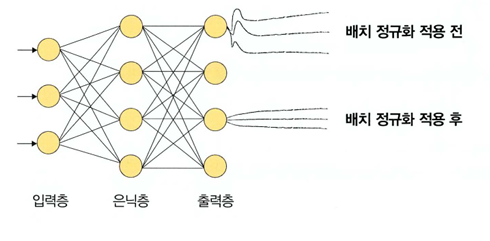

참고로 배치 정규화는 다음과 같은 위치에 놓여야 합니다.

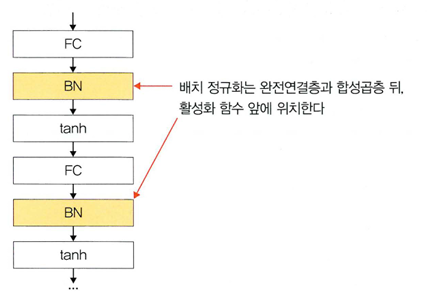

배치 정규화가 적용되지 않은 모델을 선언(객체화)합니다.

In [18]:
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


배치 정규화가 적용된 모델을 선언(객체화)합니다.

In [19]:
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


데이터로더를 이용하여 앞에서 내려받았던 데이터셋을 메모리로 불러올 준비를 합니다. 참고로 앞에서도 메모리로 불러오는 부분을 진행했습니다. 그때는 이미지 출력을 위한 용도로 배치 크기를 4로 설정했지만, 이번에 메모리로 불러오는 것은 학습을 위한 용도로 배치 크기를 512로 지정합니다.

In [20]:
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

모텔에서 사용할 옵티마이저와 손실 함수를 지정합니다.

In [21]:
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

이제 모델을 학습시켜 보겠습니다.

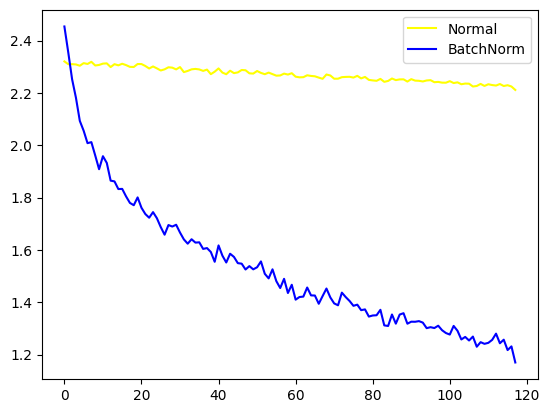

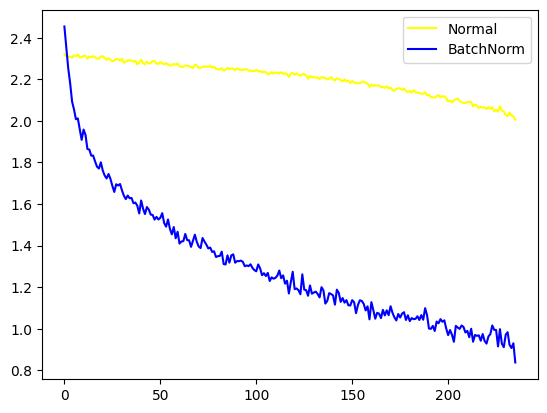

In [22]:
loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    opt.zero_grad() # 배치 정규화가 적용되지 않은 모델의 학습
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad() # 배치 정규화가 적용된 모델의 학습
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
  plt.legend()
  plt.show()

다음 그림들은 모델 학습 결과(오차 정보)를 보여 줍니다. 모델 학습 결과는 배치 정규화가 적용된 모델(위 그림의 파란색 그래프)과 적용되지 않은 모델(위 그림의 노란색 그래프)을 그래프로 출력합니다.

배치 정규화가 적용된 모델과 적용되지 않은 모델 둘 다 시간이 흐를수록 오차가 줄어드는 것을 확인할 수 있습니다. 하지만 오차가 줄어드는 범위 및 값의 차이는 명백합니다. 배치 정규화가 적용된 모델의 경우 더 낮은 값으로 안정적인 범위 내에서 줄어들고 있는 것을 확인할 수 있습니다. 즉, 다른 말로 표현하면 배치 정규화가 적용된 모댈은 에포크가 진행될수록 오차도 줄어들면서 안정적인 학습을 하고 있다고 할 수 있습니다.

배치 정규화가 성능에 어떤 영향을 미치는지 확인했다면 이번에는 드롭아웃에 대해 살펴보겠습니다.

드롭이웃을 알아보기에 앞서 훈련과 테스트 데이터셋이 어떻게 분포하는지 알아보겠습니다.

In [24]:
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1) # 1
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1)) # 2

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

1. 훈련 데이터셋이 -1~1의 값을 갖도록 조정합니다.
2. 훈련 데이터셋 값의 범위가 정규분포를 갖도록 조정합니다.

앞에서 전처리된 데이터를 그래프로 출력하여 분포를 확인합니다.

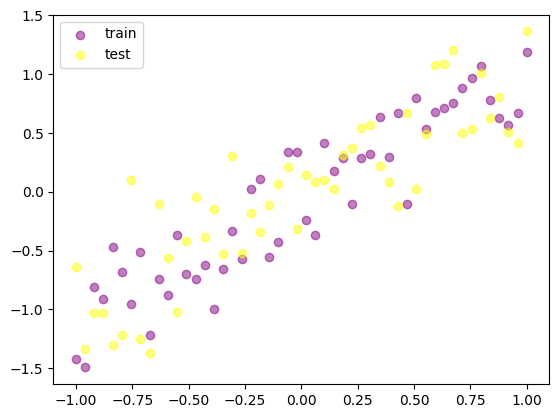

In [26]:
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c = 'purple',
            alpha = 0.5, label = 'train') # 1
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c = 'yellow',
            alpha = 0.5, label = 'test')
plt.legend()
plt.show()

1.plt.scatter()는 데이터를 그래프상에 점으로 출력해서 데이터 분포를 확인하고자 할 떄 사용합니다.

훈련과 테스트 데이터가 고르게 분포되어 있는 것을 확인할 수 있습니다.

드롭아웃의 효과를 확인하기 위해 드롭아웃이 적용된 것과 그렇지 않은 것의 모델을 생성합니다.

In [27]:
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.5),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용되지 않은 모델

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2), # 드롭아웃 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용된 모델

앞에서 생성한 모델을 위한 옵티마이저와 손실 함수를 지정합니다.

In [28]:
opt = torch.optim.Adam(model.parameters(), lr = 0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
loss_fn = torch.nn.MSELoss()

이제 드롭아웃이 적용된 모델과 그렇지 않은 모델을 학습시키고 오차를 그래프로 출력합니다.

/tmp/ipykernel_9351/3962712808.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %


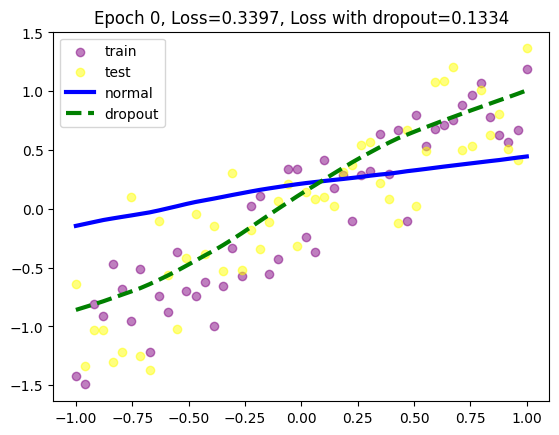

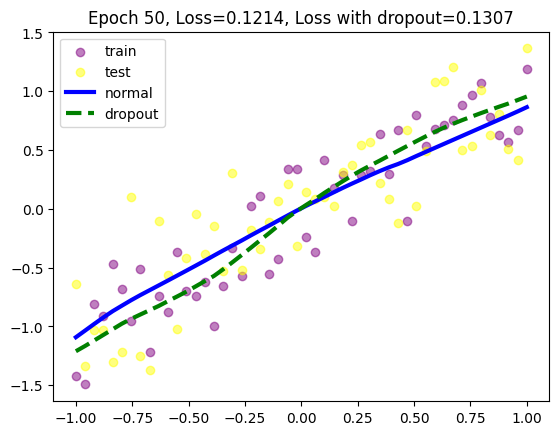

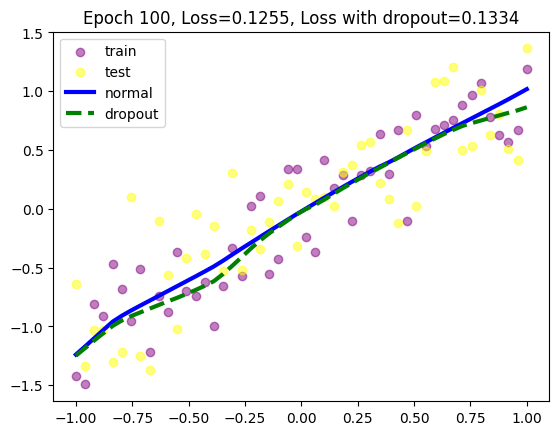

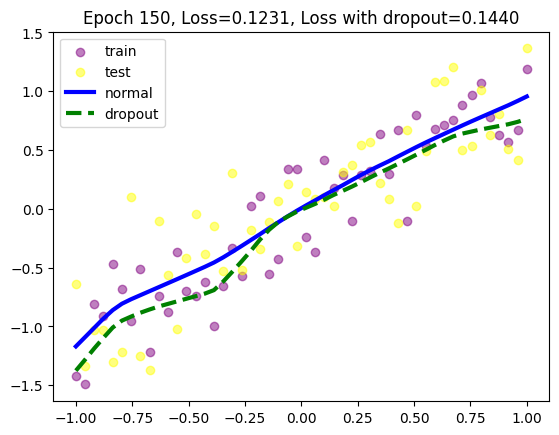

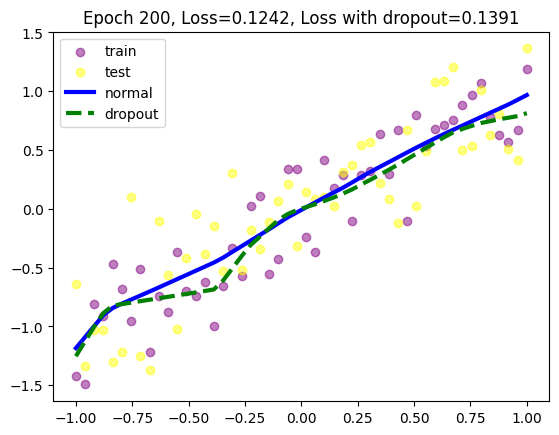

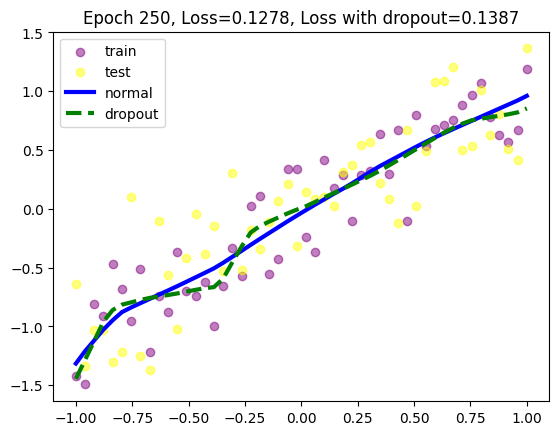

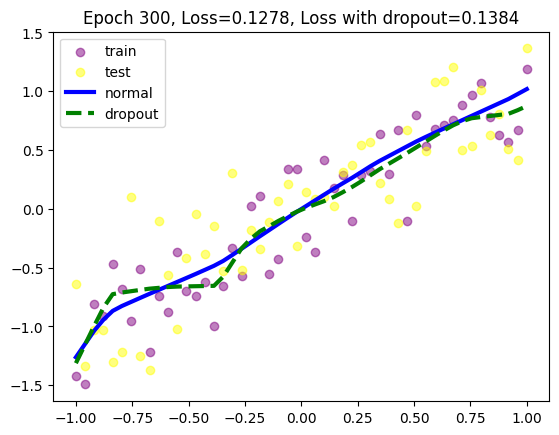

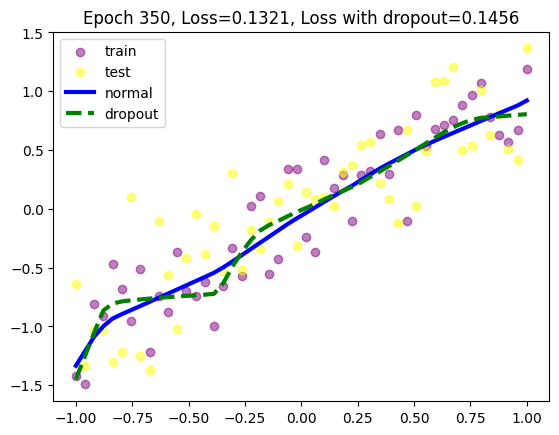

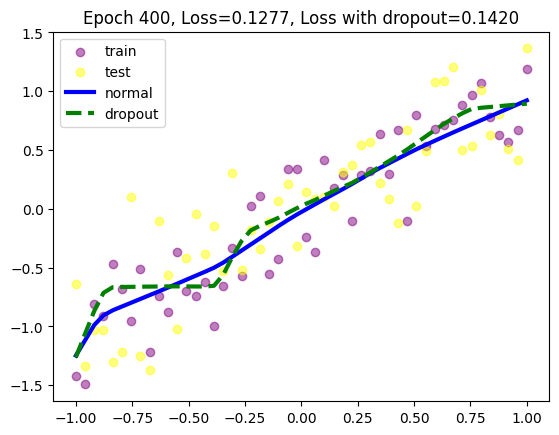

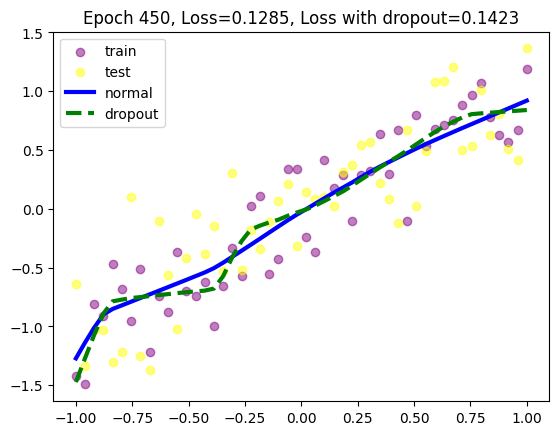

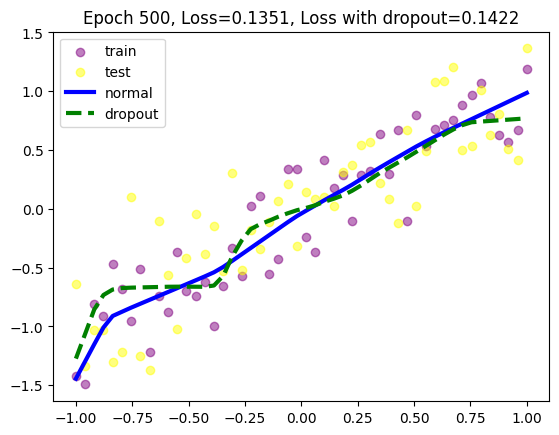

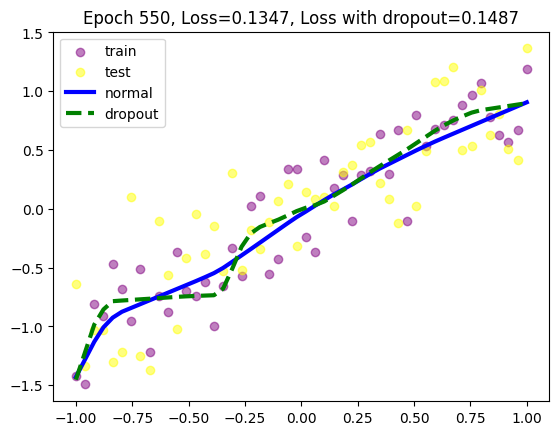

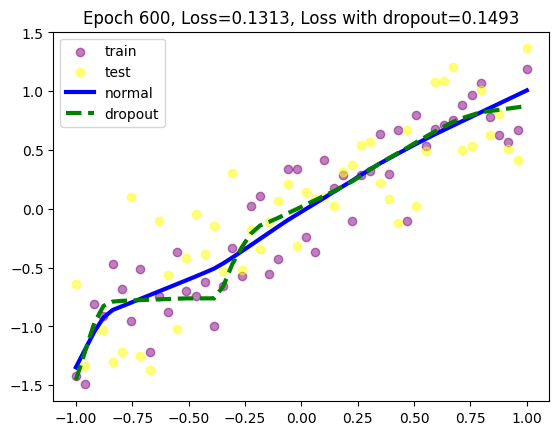

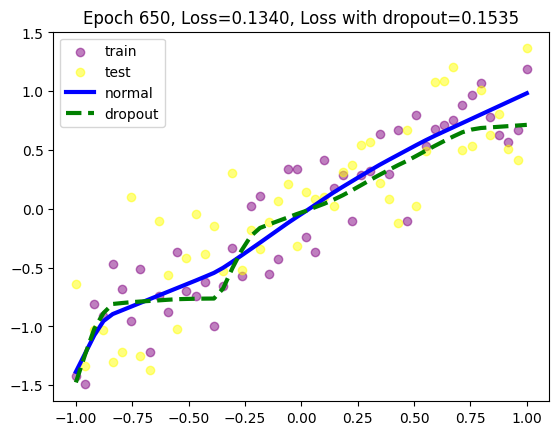

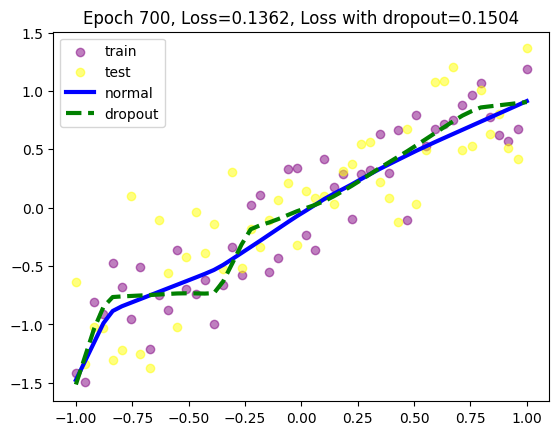

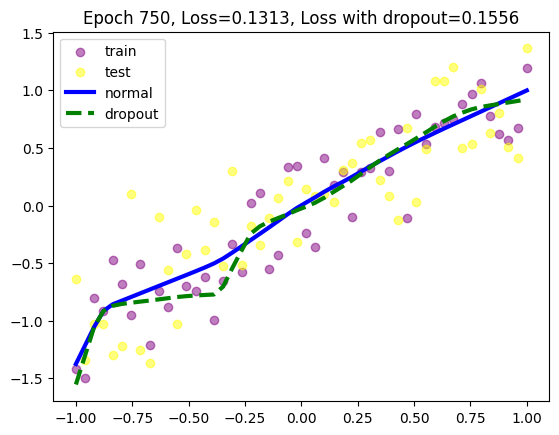

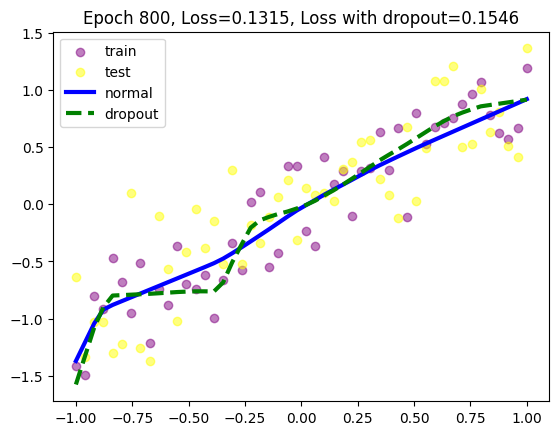

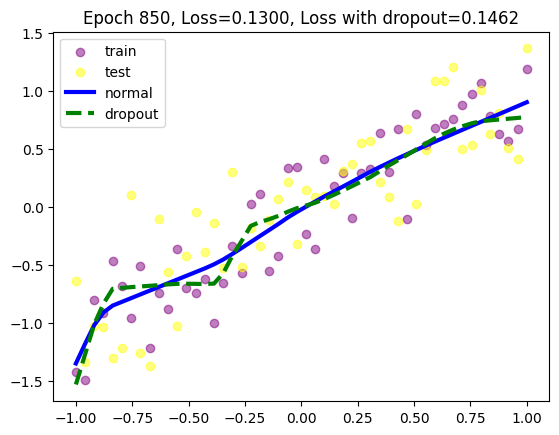

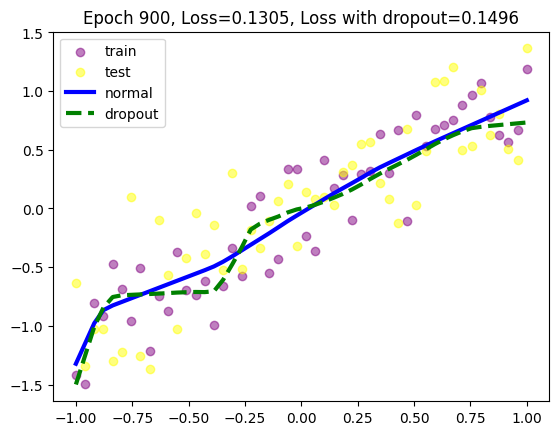

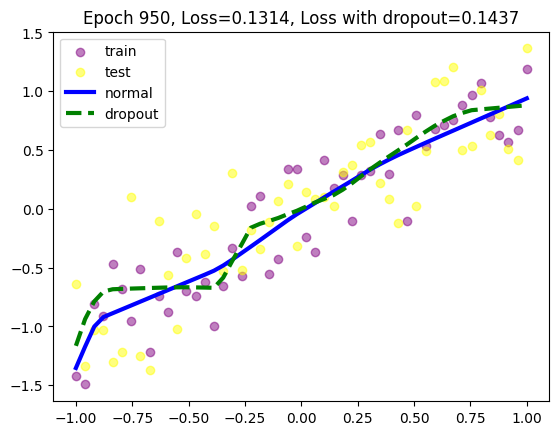

In [29]:
max_epochs = 1000
for epoch in range(max_epochs):
  pred = model(x_train) # 드롭아웃이 적용되지 않은 모델 학습
  loss = loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train) # 드롭아웃이 적용된 모델 학습
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 == 0: # epoch를 50으로 나눈 나머지가 0이면 다음 진행
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
                alpha=0.5, label='train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3,
             label='normal') # 파란색 실선으로 x축은 테스트 데이터셋, y축은 드롭아웃이 적용되지 않은 모델의 결과를 그래프로 출력
    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3,
             label='dropout') # 초록색 점선으로 x축은 테스트 데이터셋, y축은 드롭아웃이 적용된 모델의 결과를 그래프로 출력
    plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %
              (epoch, test_loss, test_loss_dropout)) # 에포크, 드롭아웃이 적용되지 않은 모델의 오차, 드롭아웃이 적용된 모델의 오차를 타이틀로 출력
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

다음 그림들은 드롭아웃과 관련된 모텔 학습 결과입니다.

전반적으로 오차가 줄어드는 범위는 크지 않습니다. 하지만 드롭아웃을 적용했을 때의 오차가 더 낮은 것을 확인할 수 있습니다. 이제 그래프를 자세히 살펴보겠습니다. 출력 결과에서 초록색 점선(드롭아웃이 적용된 모댈)과 파란색 실선(드롭아웃이 적용되지 않은 모델)의 차이가 크지 않아 보일 수 있지만 이 정도면 실제로는 큰 차이가 있는 상태입니다. 훈련 횟수가 늘어날수록 파란색 실선은 가장자리의 자주색 점들을 찾아가고 있습나다. 문제는 자쩍 선이 훈련 데이터셋을 의미한다는 것이고， 이것은 다른 의미로 과적합 현상을 보이고 있다는 것입나다. 과적합이 발생하는 모델은 훈련 데이터에 대한 정확도는 높을 수 있지만 새로운 데이터， 즉 검증 데이터나 태스트 데이터에 대해서는 제대로 동작하지 않는 문제가 있습니다. 이와 같이 과적합 현상을 방지하기 위해 드롭아웃을 시용하며 초학객 점선 그래프에서는 과적합 현상이 발생하지 않는 것을 확인할 수 있습니다.

이제 마지막으로 조기 종료에 대해 알아보겠습니다.

### 8.3.3 조기 종료를 이용한 성능 최적화
조기 종료는 뉴럴 네트워크가 과적합을 회피하는 규제 기법입니다. 훈련 데이터와 별도로 검증 데이터를 준비하고, 매 에포크마다 검증 데이터에 대한 오차를 측정하여 모델의 종료 시점을 제어합니다. 즉, 과적합이 발생하기 전까지 학습에 대한 오차와 검증에 대한 오차 모두 감소하지만, 과적합이 발생하면 훈련 데이터셋에 대한 오차는 감소하는 반면 검증 데이터셋에 대한 오차는 증가합니다. 따라서 조기 종료는 검증 데이터셋에 대한 오차가 증가하는 시점에서 학습을 멈추도록 조정합니다.

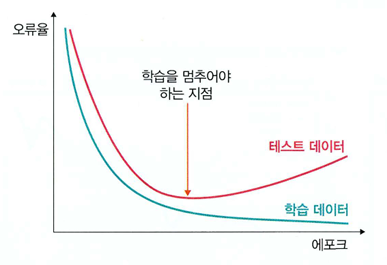

조기 종료는 학습을 언제 종료시킬지 결정할 뿐이지 최고의 성능을 갖는 모델을 보장하지는 않는다는 점에 주의해야 합니다. 이번 예제는 조기 종료뿐만 아니라 학습률을 조정해서 성능을 향상시키는 방법에 대해서도 함께 알아봅니다.

먼저 필요한 라이브러리들을 호출합니다.

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models # 사전 학습된 모델을 이용하고자 할 때 사용하는 라이브러리
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot') # 출력 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 하는 스타일
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

다음은 데이터셋 전처리를 위한 항목들을 정의합니다. 전처리에는 데이터 크기 조정 및 데이터 정규화(분포 조정) 등이 포함됩니다.

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

예제에서 사용하는 데이터셋은 핫도그와 핫도그가 아닌 이미지들을 사용합니다.

예제를 진행할 데이터셋을 배치 크기로 메모리로 가져오기 위한 준비를 합니다.

In [33]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 31.93 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [34]:
train_dataset = datasets.ImageFolder(
    root=r'080289/chap08/data/archive/train',
    transform = train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 32, shuffle = True,
)
val_dataset = datasets.ImageFolder(
    root =r'080289/chap08/data/archive/test',
    transform = val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size = 32, shuffle = False,
)

이제 모델을 생성할 댄데 네트워크를 직접 구축하는 것이 아닌 사전 학습된 ResNet50을 사용할 예정입니다. 사전 학습된 모델을 사용할 경우 간편하게 네트워크를 구성하고 사용할 수 있는 장점이 있습니다.

In [ ]:
def resnet50(pretrained=True, requires_grad=False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False: # 파라미터를 고정하여 backward() 중에 기울기가 계산되지 않도록 합니다. requires_grad=False를 파라미터로 받았기 때문에 해당 구문이 실행됩니다.
    for param in model.parameters():
      param.requires_grad = False
  elif requires_grad == True: # 파라미터 값이 backward() 중에 기울기 게산에 반영됩니다.
    for param in model.parameters():
      param.requires_grad = True
  model.fc = nn.LInear(2048, 2) # 마지막 분류를 위한 계층은 학습을 진행합니다.
  return model

파이토치에서 조기 종료와 함께 지주 사용되는 것으로 학습률 감소라는 것이
있습니다. 학습률에 대한 값을 고정시켜서 모델을 학습시커는 것이 아니라 학습이 진행되는 과정에서 학습률을 조금씩 낮추어 주는 성능 튜닝 기법 중에 하나입니다. 학습률 감소는 학습률 스케줄러라는 것을 이용하는데, 주어진 'patience' 횟수만큼 검증 데이터셋에 대한 오차 감소가 없으면 역시 주어진 'factor'만큼 학습률을 감소시켜서 모델 학습의 최적화가 가능하도록 도외줍니다. 다음 코드를 통해 자세히 살펴보겠습니다.

In [35]:
class LRScheduler():
  def __init__(
      self, optimizer, patience = 5, min_lr = 1e-6, factor = 0.5
  ):
      self.optimizer = optimizer
      self.patience = patience
      self.min_lr = min_lr
      self.factor = factor
      self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
          self.optimizer,
          mode = 'min',
          patience = self.patience,
          factor = self.factor,
          min_lr = self.min_lr,
          verbose = True
      ) # 1

  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss) # 2

1. 학습 과정에서 모델 성능에 대한 계산이 없을 경우 학습률 값을 조절하여 모델의 개선을 유도하는 콜백 합수입니다.
2. 실제로 학습률을 업데이트합니다. 에포크 단위로 검증 데이터셋에 대한 오차를 받아서 이전 오차와 비교했을 때 차이가 없다면 학습률을 업데이트합니다.

이번에는 조기 종료에 대한 클래스입니다. 특정 에포크 후에도 오차가 개선되지 않을 때 훈련을 조기 종료합니다.

In [41]:
class EarlyStopping():
  def __init__(self, patience = 5, verbose=False, delta=0,
               path = '080289/chap08/data/checkpoint.pt'):
    self.patience = patience # 1
    self.verbose = verbose
    self.coutner = 0
    self.best_score = None # 검증 데이터셋에 대한 오차 최적화 값(오차가 가장 낮은 값)
    self.early_stop = False # 조기 종료를 의미하며 초깃값은 False로 설정
    self.val_loss_min = np.Inf # np.Inf(infinity)는 넘파이에서 무한대를 표현
    self.delta = delta # 2
    self.path = path # 모델이 저장될 경로

  def __call__(self, val_loss, model): # 에포크만큼 학습이 반복되면서 best_loss가 갱신되고, best_loss에 진전이 없으면 조기 종료한 후 모델을 저장
    score = -val_loss
    if self.best_score is None: # best_score에 값이 존재하지 않으면 실행
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta: # best_score + delta가 score보다 크면 실행
      self.counter += 1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
    else: # 그 외 모든 경우에 실행
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model): # 검증 데이터셋에 대한 오차가 감소하면 모델을 저장
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
    torch.save(model.state_dict(), self.path) # 지정된 경로에 모델 저장
    self.val_loss_min = val_loss

1. patience: 오차 개선이 없다고 바로 종료하지 않고 개선이 없는 에포크를 얼마나 기다려 줄지 지정합니다.
2. delta: 오차가 개선되고 있다고 판단하기 위한 최소 변화량을 나타법니다. 변화량이 de1ta보다 적다면 개선이 없다고 판단합니다.

일반적으로 케라스에서 제공하는 콜백(keras.callbacks)을 이용하면 손쉽게 조기 종료를 구현할 수 있지만 파이토치에서는 조기 종료 함수 자체를 사용자가 직접 구현해야 합니다. 이러한 과정이 번거롭다면 케라스를 이용하면 편리합니다.

예제는 학습률 감소와 조기 종료 두 개에 대한 성능 튜닝을 진행하고 있습니다. 즉, 함수에 넘겨주는 인수 값에 따라 다른 동작을 하도록 해야 하는데 이때 시용할 수 있는 것이 argparse 라이브러리입니다. ArgumentParser()를 이용하여 변수와 타입을 정의해 주고 add_argument()를 이용해서 변수에 인수 값을 하나씩 추가합니다. 그리고 마지막으로 parse_args()를 통해 사용자로부터 입력받은 값들을 args 변수에 저장합니다.

In [42]:
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest = 'lr_scheduler', action = 'store_true') # 1
parser.add_argument('--early-stopping', dest = 'early_stopping', action = 'store_true') # 조기 종료에 대한 인수
args, unknown = parser.parse_known_args() # 2
args = vars(args)

1. 원하는 인수 값을 추가합니다. 이때 parser.add_argumet()는 인수 개수만큼 만들어 줍니다.
2. 입력받은 인수 값이 실제로 args 변수에 저장됩니다.

In [44]:
print(f"Computation device: {device}\n") # CPU를 사용하는지 GPU를 사용하는지 검사
model = models.resnet50(pretrained=True).to(device) # 사전 훈련된 ResNet50 사용
total_params = sum(p.numel() for p in model.parameters()) # 총 파라미터 수
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad) # 학습 가능한 파라미터 수
print(f"{total_trainable_params:,} training parameters.")

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


전체 파라미터와 학습 가능한 파라미터는 25,557,0327R라는 것을 보여줍니다.

초기 학습률, 에포크 및 옵티마이저와 손실 함수를 지정합니다.

In [45]:
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr = lr)
criterion = nn.CrossEntropyLoss()

'--lr-scheduler' 또는 '--early-stopping' 처럼 어 떤 인수도 사용하지 않을 때 오차, 정확도 및 모델의 이름으로 사용할 문자열을 지정합니다.

In [46]:
loss_plot_name = 'loss' # 오차 출력에 대한 문자열
acc_plot_name = 'accuracy' # 정확도 출력에 대한 문자열
model_name = 'model' # 모델을 저장하기 위한 문자열

'--lr-scheduler' 또는 '--early-stopping' 인수를 사용할 경우 오차, 정확도 및 모델의 이름으로 사용할 문자열을 지정합니다.

In [47]:
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss' # 학습률 감소를 적용했을 때의 오차에 대한 문자열
  acc_plt_name = 'lrs_accuracy' # 학습률 감소를 적용했을 때의 정확도에 대한 문자열
  model_name = 'lrs_model' # 학습률 감소를 적용했을 때의 모델에 대한 문자열
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss' # 조기 종료를 적용했을 때의 오차에 대한 문자열
  acc_plot_name = 'es_accuracy' # 조기 종료를 적용했을 때의 정확도에 대한 문자열
  model_name = 'es_model' # 조기 종료를 적용했을 때의 모델에 대한 문자열

훈련 데이터셋을 이용한 모델 학습 함수를 정의합니다.

In [48]:
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss = 0.0
  train_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(train_dataloader), total = int(len(train_dataset)/
                                                           train_dataloader.batch_size)) # 훈련 진행 과정을 시각적으로 표현
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total += target.size(0)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

다음은 모델 성능을 검증하기 위한 함수입니다.

In [49]:
def validate(model, test_dataloader, val_dataset, criterion):
  print('Validating')
  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/
                                                        test_dataloader.batch_size)) # 모델 검증 과정을 시각적으로 표현
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total += target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

데이터셋과 모델에 대한 준비가 완료되었습니다. 이제 모델을 학습시켜 보겠습니다.

In [50]:
train_loss, train_accuracy = [], [] # 훈련 데이터셋을 이용한 모델 학습 결과(오차, 정확도)를 저장하기 위한 변수(리스트 형태를 갖습니다)
val_loss, val_accuracy = [], [] # 검증 데이터셋을 이용한 모델 성능 결과(오차, 정확도)를 저장하기 위한 변수(리스트 형태를 갖습니다)

start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(
      model, train_dataloader, train_dataset, optimizer, criterion
  )
  val_epoch_loss, val_epoch_accuracy = validate(
      model, val_dataloader, val_dataset, criterion
  )
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']: # 인수 값이 lr_scheduler이면 다음을 실행
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']: # 인수 값이 early_stopping이면 다음을 실행
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
  end = time.time()
  print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [00:06,  2.45it/s]


Validating


16it [00:03,  4.67it/s]


Train Loss: 2.4767, Train Acc: 55.22
Val Loss: 15.2361, Val Acc: 50.00
Training time: 0.166 minutes
Epoch 2 of 100
Training


...

Train Loss: 0.0161, Train Acc: 99.60
Val Loss: 0.9892, Val Acc: 76.20
Training time: 14.769 minutes
Epoch 100 of 100
Training


16it [00:04,  3.22it/s]


Validating


16it [00:04,  3.96it/s]

Train Loss: 0.0170, Train Acc: 99.40
Val Loss: 0.9244, Val Acc: 77.40
Training time: 14.920 minutes


마지막으로 모델의 정확도와 오치를 그래프를 통해서 확인해 보겠습니다. 이때 출력 결과는 어떤 인수도 사용되는 않는 모델의 학습 결과입니다.

Saving loss and accuracy plots...


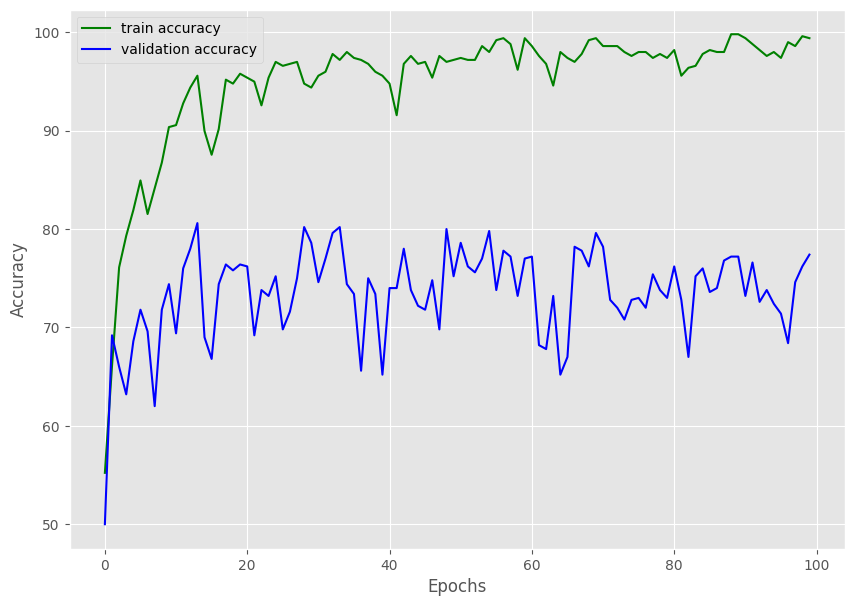

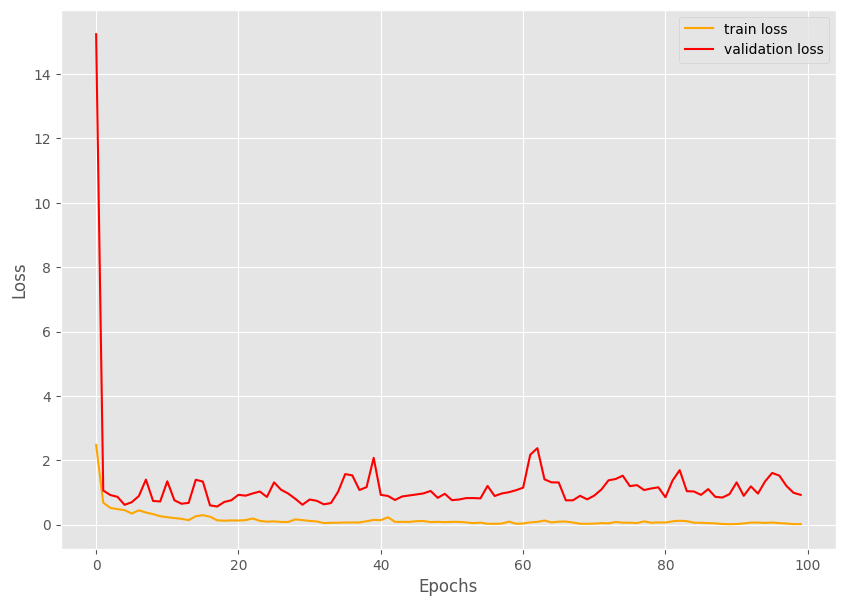

Saving model...
TRAINING COMPLETE


In [51]:
print('Saving loss and accuracy plots...')
plt.figure(figsize = (10, 7))
plt.plot(train_accuracy, color = 'green', label = 'train accuracy') # 훈련 데이터셋에 대한 정확도를 그래프로 출력
plt.plot(val_accuracy, color = 'blue', label = 'validation accuracy') # 검증 데이터셋에 대한 정확도를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'080289/chap08/data/{acc_plot_name}.png')
plt.show()
plt.figure(figsize = (10, 7))
plt.plot(train_loss, color = 'orange', label = 'train loss') # 훈련 데이터셋에 대한 오차를 그래프로 출력
plt.plot(val_loss, color = 'red', label = 'validation loss') # 검증 데이터셋에 대한 오차를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'080289/chap08/data/{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'080289/chap08/data/{model_name}.pt') # 모델을 저장
print('TRAINING COMPLETE')

정확도의 경우 위아래로 많은 변동이 있는 것을 볼 수 있습니다. 정확도가 10% 이상 차이가 나는 일부 에포크 사이는 기복이 매우 심합니다. 오차에 대한 그래프도 크게 다르지 않습니다. 특히 에포크 10 이후부터 검증 데이터셋에 대한 오차가 미세한 차이로 우상향하는 것을 볼 수 있습니다. 이것은 모델이 과적합되기 시작했으며 적절한 훈련을 계속하려면 학습률 값을 줄여야 한다는 것을 보여줍니다.

명심해야 할 것은 조기 종료가 항상 성능에 좋은 영향을 미치는 것은 아닙니다. 조기 종료로 인해 모벨이 제대로 학습하지 못할 수 있습니다. 실제로 검증 데이터셋에 대한 정확도 그래프가 위아래로 오가면서 불안정한 결과를 출력하고 있습니다. 그렇다고 학습을 계속 이어 간다고 해서 더 좋은 결과를 얻을 수 있다는 보장도 없습니다. 따라서 그래프가 의미하는 내용을 잘 이해하고 적절한 성능 향상 방안을 적용하는 것이 중요합니다. 앞에서 검증 데이터셋에 대한 정확도는 좋지 않지만, 오차는 많이 낮아진 것을 확인할 수 있습니다. 따라서 정확도만 보고 조기 종료가 효과가 없다고 판단하기에는 숲이 아닌 나무만 보고 판단한 결과와 같습니다.

분명한 것은 학습률 스케줄러를 이용한 학습률 조정 기법과 조기 종료가 모댈 성능을 향상시키는 데는 도움이 된다는 것입니다. 단 모든 모댈에 일괄적으로 적용하는 것이 아닌, 기존의 출력된 그래프를 해석해서 어떤 성능 기법을 적용할지 결정하는 것이 중요합니다.